In [19]:
! pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [1]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Optional, Union, List, Dict, Any
import pathlib
from pathlib import Path
from matplotlib.ticker import MaxNLocator
from sklearn.base import BaseEstimator
from sklearn.utils.validation import check_is_fitted

# --- ROBUST ROOT DISCOVERY ---
def find_project_root(marker: str = "pyproject.toml") -> Path:
    """Locates the project root by searching upwards from the notebook location."""
    try:
        start_dir = Path(globals().get('_dh', [os.getcwd()])[0]).resolve()
    except (IndexError, NameError):
        start_dir = Path.cwd().resolve()

    current = start_dir
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
            
    # Fallback
    fallback = Path(r"C:\Users\ggrmi\Documents\IC Tarcísio\Sound of Rainfall\Rainfall-opensense_2026")
    return fallback if (fallback / marker).exists() else start_dir

# Detect & Set Root
project_root = find_project_root()
if Path.cwd() != project_root:
    os.chdir(project_root)
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))

print(f"✅ Project Root: {project_root}")

✅ Project Root: C:\Users\ggrmi\Documents\IC Tarcísio\Sound of Rainfall\Rainfall-opensense_2026


In [2]:
@dataclass(frozen=True)
class VisualizationConfig:
    DEFAULT_OUTPUT_DIR: str = "reports/figures"
    IEEE_STYLE: Dict[str, Any] = field(default_factory=lambda: {
        'pdf.fonttype': 42,
        'font.family': 'serif',
        'font.serif': ['Times New Roman'],
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'legend.fontsize': 9,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'figure.dpi': 300,
        'savefig.bbox': 'tight',
        'axes.grid': False # Disabled global grid for cleaner matrices
    })

CONFIG = VisualizationConfig()

class VisualizationCore(BaseEstimator):
    def __init__(self, output_dir=CONFIG.DEFAULT_OUTPUT_DIR):
        self.output_dir = output_dir
        self.is_fitted_ = False

    def fit(self, X=None, y=None):
        self.validated_output_path_ = pathlib.Path(self.output_dir).resolve()
        self.validated_output_path_.mkdir(parents=True, exist_ok=True)
        self.style_context_ = CONFIG.IEEE_STYLE.copy()
        self.is_fitted_ = True
        return self

    def save(self, fig, filename):
        for fmt in ['pdf', 'png']:
            path = self.validated_output_path_ / f"{filename}.{fmt}"
            fig.savefig(path, format=fmt, dpi=300)

viz_core = VisualizationCore().fit()

In [3]:
# =============================================================================
# 2. INGESTÃO E LIMPEZA DE DADOS (ETL)
# =============================================================================
print("⏳ Carregando planilhas...")
# Carregando 2023-2024
caminho_23_24 = project_root / "data" / "raw" / "Eventos 2023-2024.xlsx"
df_23_24 = pd.read_excel(caminho_23_24, sheet_name="ENTRADA DE DADOS (2)")
# Padronizando colunas
df_23_24 = df_23_24[['DATA', 'PRECIPITAÇÃO (mm)']].copy()
df_23_24.columns = ['data_hora', 'precipitacao']
df_23_24['data_hora'] = pd.to_datetime(df_23_24['data_hora'])

# Carregando 2025 (Puxa todas as abas automaticamente)
caminho_25 = project_root / "data" / "raw" / "Eventos 2025.xlsx"
xls_25 = pd.ExcelFile(caminho_25)
df_25_list = []

for sheet in xls_25.sheet_names:
    # skiprows=1 ignora o cabeçalho sujo 'Gráficos Listagem,,'
    df_temp = pd.read_excel(caminho_25, sheet_name=sheet, skiprows=1) 
    if 'Data' in df_temp.columns and 'Chuva' in df_temp.columns:
        df_temp = df_temp[['Data', 'Chuva']].copy()
        df_temp.columns = ['data_hora', 'precipitacao']
        # Faz o parse da data com formato brasileiro
        df_temp['data_hora'] = pd.to_datetime(df_temp['data_hora'], dayfirst=True, errors='coerce')
        df_25_list.append(df_temp)

df_25 = pd.concat(df_25_list, ignore_index=True)

# Unindo tudo em um único Dataframe
df_all = pd.concat([df_23_24, df_25], ignore_index=True)
# Força numérico e lida com eventuais vazios
df_all['precipitacao'] = pd.to_numeric(df_all['precipitacao'], errors='coerce')

⏳ Carregando planilhas...


In [4]:
# =============================================================================
# 3. FILTRAGEM (QUADRA CHUVOSA EXTENDIDA E SEM SILÊNCIO)
# =============================================================================
# Extrai o mês
df_all['mes'] = df_all['data_hora'].dt.month

# FILTRO CRÍTICO: 
# 1. Apenas meses de 1 a 7 (Jan a Julho)
# 2. Apenas PRECIPITAÇÃO > 0 (Se não removermos o 0, o Boxplot fica plano)
df_chuva = df_all[(df_all['mes'].isin([1, 2, 3, 4, 5, 6, 7])) & (df_all['precipitacao'] > 0)].copy()

# Mapeando números para nomes de meses para ficar elegante no artigo
meses_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul'}
df_chuva['mes_nome'] = df_chuva['mes'].map(meses_map)
# Garante a ordem correta no eixo X
df_chuva['mes_nome'] = pd.Categorical(df_chuva['mes_nome'], categories=meses_map.values(), ordered=True)

print(f"✅ Dados processados! Total de eventos com chuva real analisados: {len(df_chuva)}")

✅ Dados processados! Total de eventos com chuva real analisados: 4155


C:\Users\ggrmi\AppData\Local\Temp\ipykernel_22716\3498677093.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


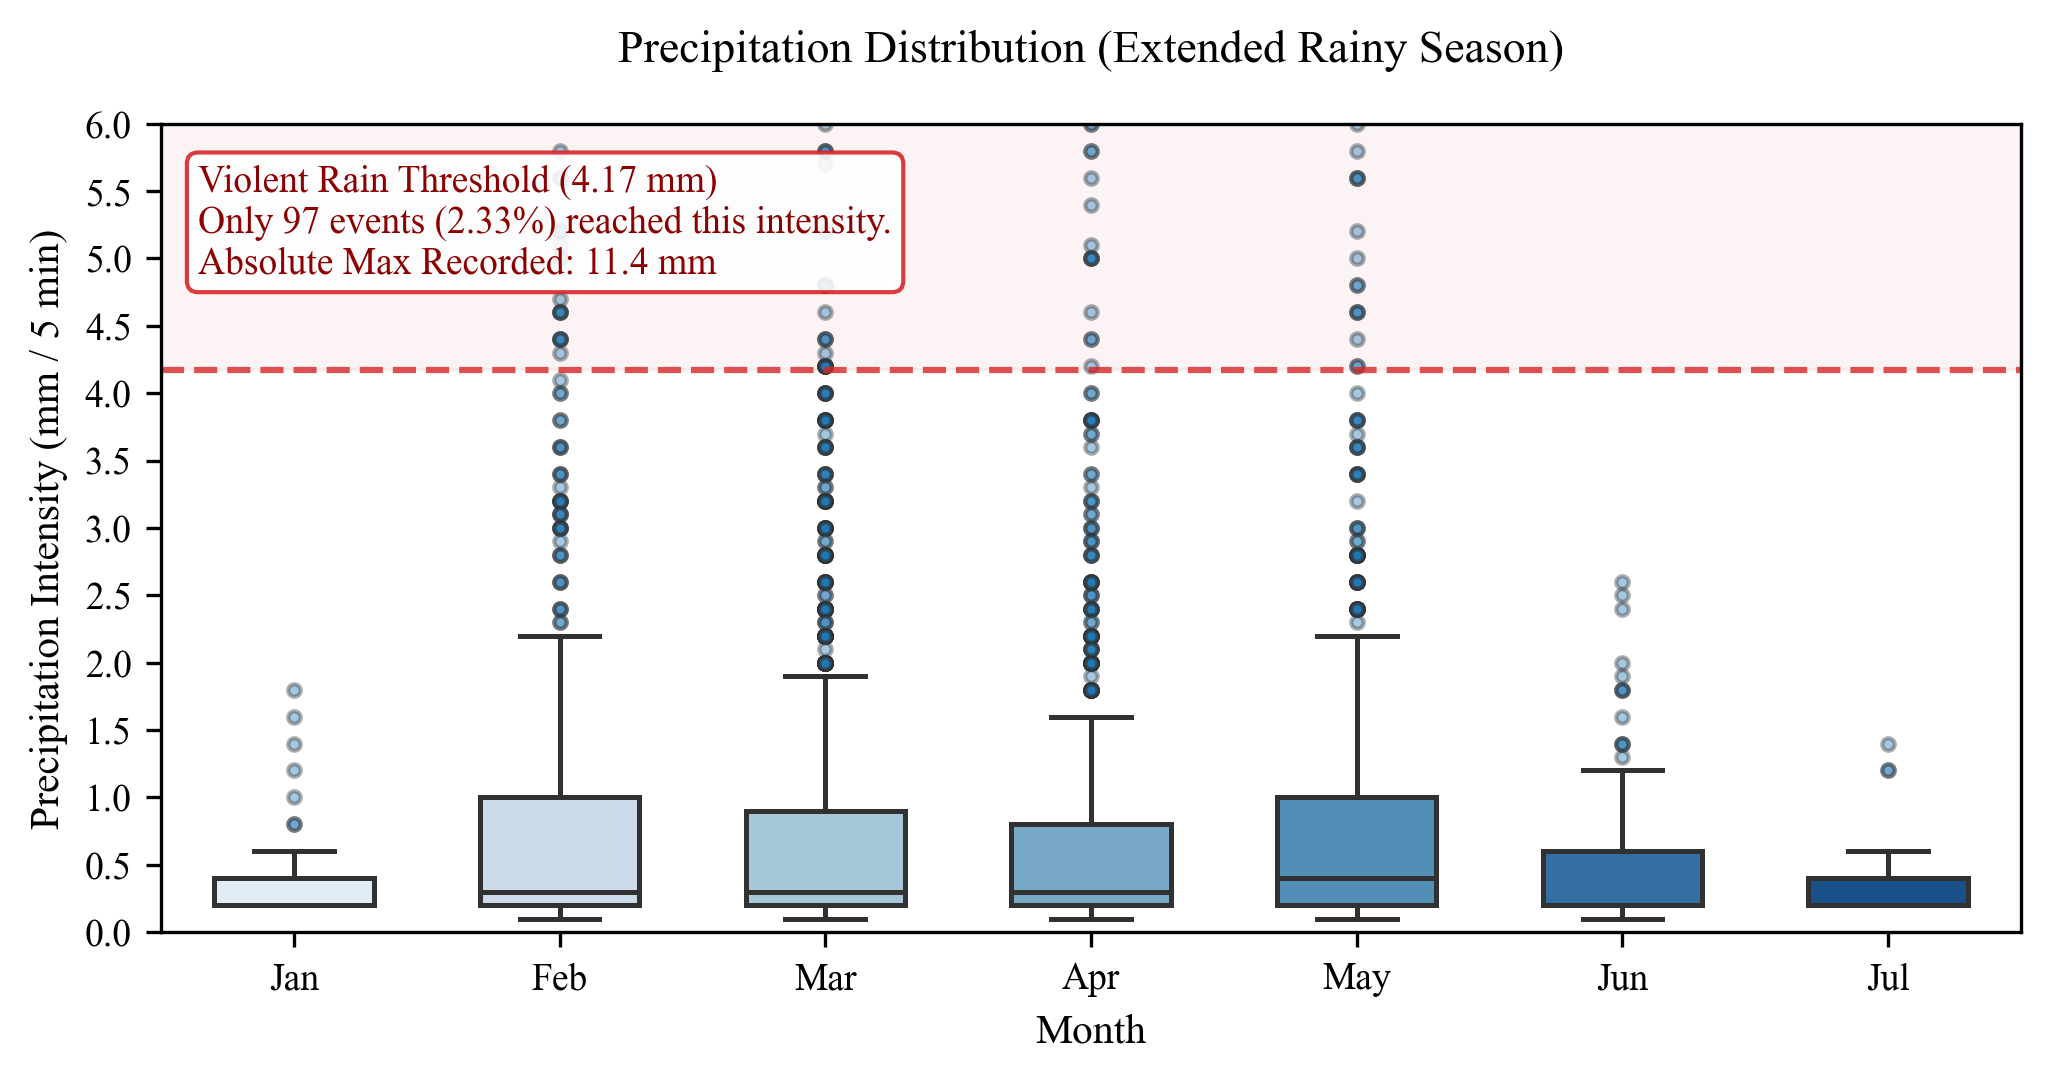

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

# =============================================================================
# 4. PLOTAGEM DO BOXPLOT (FOCO NA RARIDADE DA CHUVA VIOLENTA)
# =============================================================================
# Calculando a raridade matematicamente para colocar no gráfico
total_eventos = len(df_chuva)
violentas = len(df_chuva[df_chuva['precipitacao'] >= 4.17])
percentual = (violentas / total_eventos) * 100
max_precip = df_chuva['precipitacao'].max()

with plt.style.context(viz_core.style_context_):
    fig, ax = plt.subplots(figsize=(8, 3.5))
    
    sns.boxplot(
        data=df_chuva, 
        x='mes_nome', 
        y='precipitacao', 
        palette="Blues", 
        width=0.6,
        ax=ax,
        linewidth=1.2,
        fliersize=3,
        flierprops={"marker": "o", "alpha": 0.4, "markerfacecolor": "#1f77b4"}
    )
    
    # 1. Destacando a Chuva Violenta (Linha e Sombra)
    limiar_violenta = 4.17
    limite_visual_y = 6.0 # Até onde o gráfico vai ser renderizado
    
    ax.axhline(limiar_violenta, color='#d62728', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.axhspan(limiar_violenta, limite_visual_y, color='#d62728', alpha=0.05)
    
    # 2. Caixa de Texto contando a história dos dados
    texto_raridade = (
        f"Violent Rain Threshold (4.17 mm)\n"
        f"Only {violentas} events ({percentual:.2f}%) reached this intensity.\n"
        f"Absolute Max Recorded: {max_precip:.1f} mm"
    )
    # Posição da caixa: 2% no eixo X, 95% no eixo Y (canto superior esquerdo)
    ax.text(0.02, 0.95, texto_raridade, transform=ax.transAxes, 
            fontsize=9, color='#8b0000', va='top', ha='left', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#d62728'))

    ax.set_title("Precipitation Distribution (Extended Rainy Season)", pad=15)
    ax.set_xlabel("Month")
    ax.set_ylabel("Precipitation Intensity (mm / 5 min)")
    
    # 3. O "Zoom" Visual (Restringe o Y para não ser esmagado pelo outlier absoluto)
    ax.set_ylim(0, limite_visual_y) 
    ax.yaxis.set_major_locator(MultipleLocator(0.5))
    
    # Salva em PDF e PNG
    viz_core.save(fig, "boxplot_precipitation_jan_jul_violent_highlight")
    plt.show()

⏳ Carregando dados da FUNCEME...
✅ Dados processados! Total de dias analisados: 5513


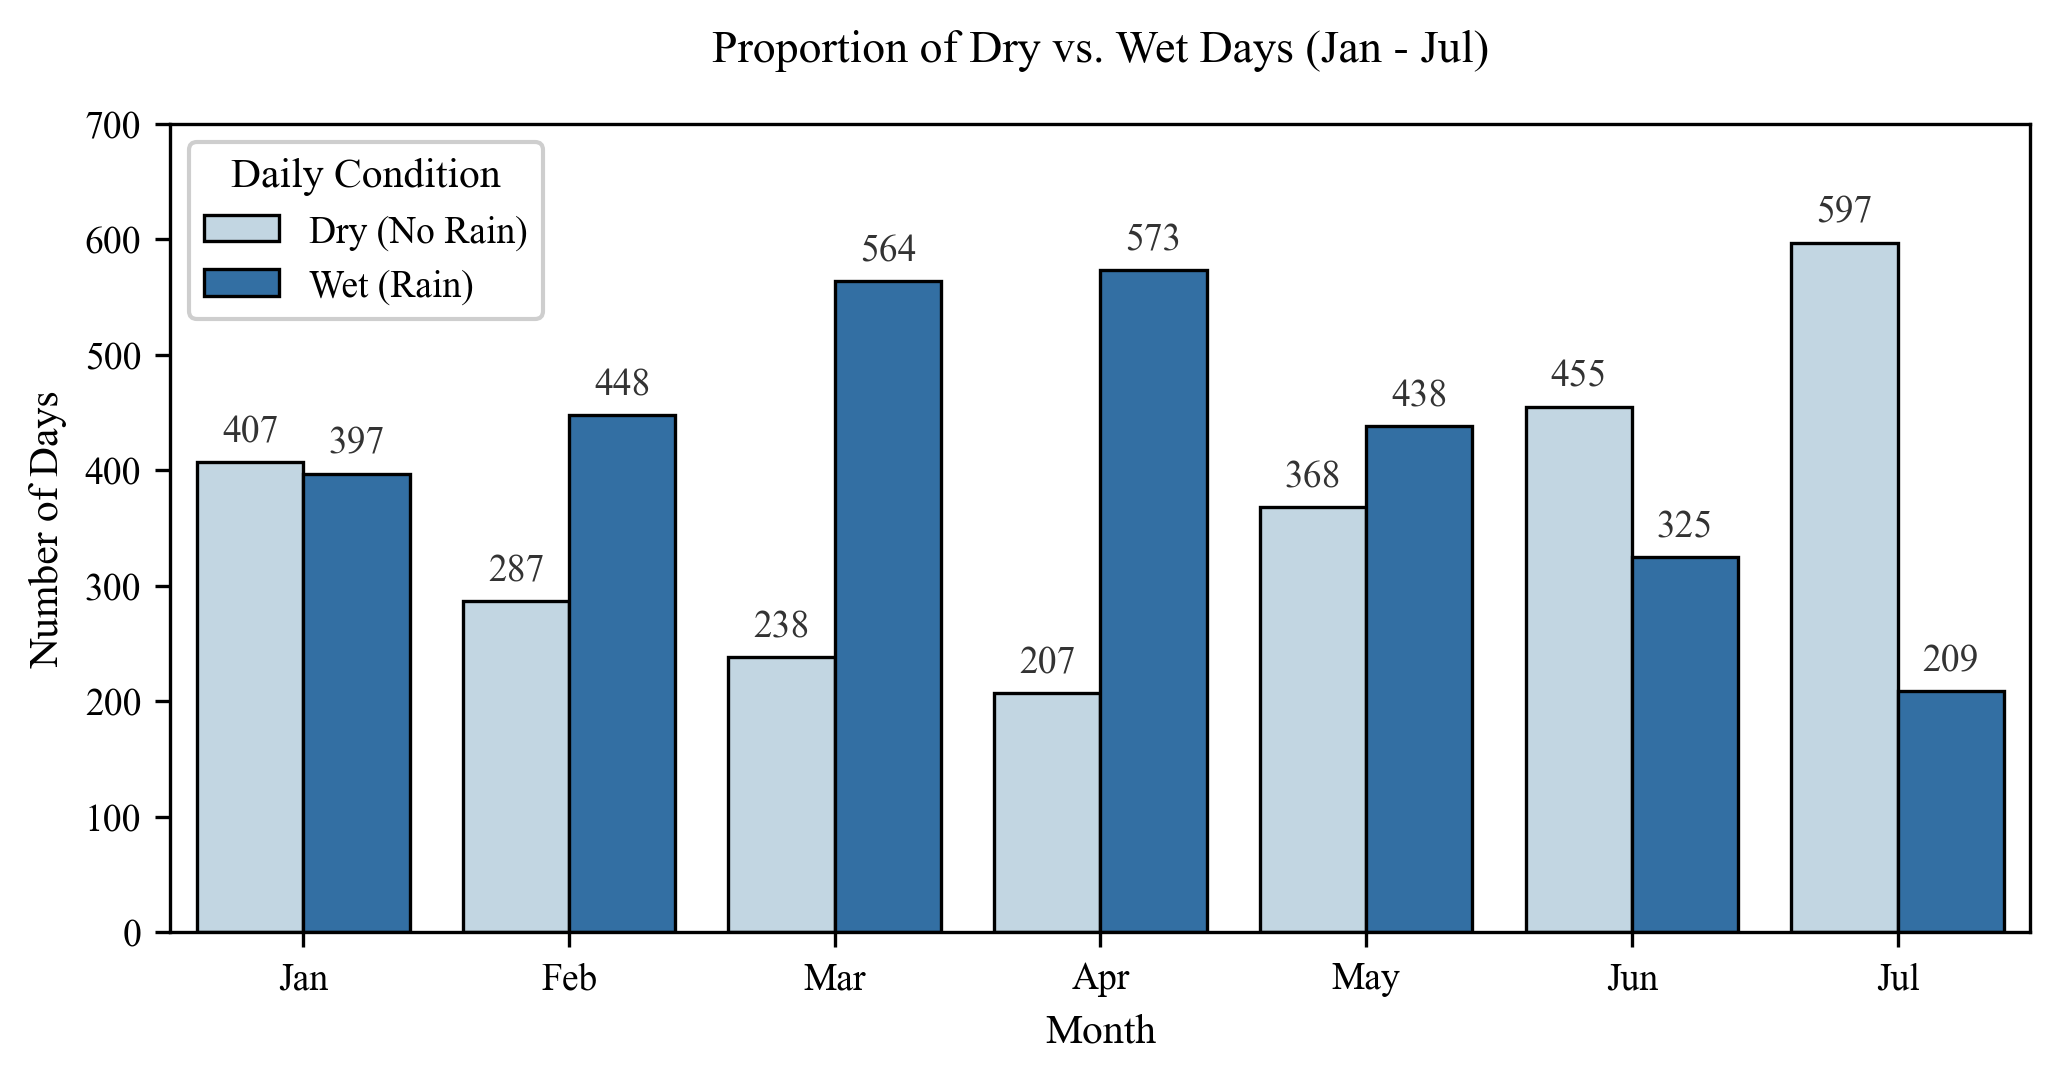

In [8]:
# =============================================================================
# 1. INGESTÃO E LIMPEZA DE DADOS (FUNCEME)
# =============================================================================
print("⏳ Carregando dados da FUNCEME...")

caminho_funceme = project_root / "data" / "raw" / "PluviometriaFuncemeNormalizada_2026-03-04T15_35_56.csv"
df_funceme = pd.read_csv(caminho_funceme, sep=';')

df_funceme['data'] = pd.to_datetime(df_funceme['data'])
df_funceme['mes'] = df_funceme['data'].dt.month

df_funceme_filtro = df_funceme[df_funceme['mes'].isin([1, 2, 3, 4, 5, 6, 7])].copy()
df_funceme_filtro['Status'] = df_funceme_filtro['valor'].apply(lambda x: 'Wet (Rain)' if x > 0 else 'Dry (No Rain)')

meses_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul'}
df_funceme_filtro['mes_nome'] = df_funceme_filtro['mes'].map(meses_map)
df_funceme_filtro['mes_nome'] = pd.Categorical(df_funceme_filtro['mes_nome'], categories=meses_map.values(), ordered=True)

df_contagem = df_funceme_filtro.groupby(['mes_nome', 'Status']).size().reset_index(name='Days')

print(f"✅ Dados processados! Total de dias analisados: {len(df_funceme_filtro)}")

# =============================================================================
# 2. PLOTAGEM DO GRÁFICO (WET vs DRY - AJUSTADO PARA O ARTIGO)
# =============================================================================
with plt.style.context(viz_core.style_context_):
    fig, ax = plt.subplots(figsize=(8, 3.5))
    
    # Paleta alinhada com o Boxplot ("Blues"): Azul claro (Dry) e Azul escuro (Wet)
    custom_palette = {'Dry (No Rain)': '#bdd7e7', 'Wet (Rain)': '#2171b5'}
    
    sns.barplot(
        data=df_contagem, 
        x='mes_nome', 
        y='Days', 
        hue='Status', 
        palette=custom_palette,
        edgecolor='black', 
        linewidth=0.8,
        ax=ax
    )
    
    ax.set_title("Proportion of Dry vs. Wet Days (Jan - Jul)", pad=15)
    ax.set_xlabel("Month")
    ax.set_ylabel("Number of Days")
    
    # Trava o eixo Y em 700, conforme solicitado
    ax.set_ylim(0, 700)
    
    # Legenda ancorada à esquerda e dentro do gráfico
    ax.legend(title="Daily Condition", loc='upper left', framealpha=0.95)
    
    # Rótulos numéricos nas barras
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9, color='#333333')
        
    viz_core.save(fig, "barplot_dry_vs_wet_funceme_final")
    
    plt.show()